## ATSEviz: Visualizing Alternative Splicing Events
This notebook demonstrates how to use the ATSEviz module from LeafletFA-utils to visualize alternative splicing events.

In [1]:
# Import necessary libraries
import pandas as pd
import os
import sys
import pandas as pd
import numpy as np
from typing import List, Set

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper
from leafletfa_utils.atseviz.main import *

# Check that imports worked
print("Imports successful!")

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!


In [2]:
db_file = "/gpfs/commons/home/kisaev/LeafletFA-utils/examples/LeafletFA_ATSE_mapper_output_20250401_150841/annotation.db"
db = gffutils.FeatureDB(db_file, keep_order=True)

In [12]:
# Visualize random ATSEs
p=pd.read_csv("/gpfs/commons/home/kisaev/LeafletFA-utils/LeafletFA_ATSE_mapper_output_20250426_155744/atse_events_20250426-161546.tsv.gz", sep="\t")
atse_event = p.sample(1)["event_id"].values[0]

# Create a copy of the subset to avoid SettingWithCopyWarning
juncs = p[p["event_id"] == atse_event].copy()

# Use .loc to set values
juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
juncs.loc[:, "Cluster"] = juncs["event_id"]

# Now convert junction IDs
splice_junctions = convert_junction_ids(juncs)
splice_junctions

[{'chrom': 'chr7',
  'start': 126797776,
  'end': 126800001,
  'name': 'junction_155',
  'strand': '-',
  'usage_ratio': 0.08467893353360871},
 {'chrom': 'chr7',
  'start': 126797776,
  'end': 126800287,
  'name': 'junction_156',
  'strand': '-',
  'usage_ratio': 0.07435223432219301},
 {'chrom': 'chr7',
  'start': 126797776,
  'end': 126799044,
  'name': 'junction_157',
  'strand': '-',
  'usage_ratio': 0.8409688321441983}]

Found 11 unique transcripts
                      transcript_name       transcript_type  \
ENSMUST00000032934.11       Aldoa-201        protein_coding   
ENSMUST00000087566.10       Aldoa-202        protein_coding   
ENSMUST00000106348.7        Aldoa-203        protein_coding   
ENSMUST00000133514.7        Aldoa-204        protein_coding   
ENSMUST00000135707.7        Aldoa-205  processed_transcript   
ENSMUST00000141355.3        Aldoa-207        protein_coding   
ENSMUST00000143509.7        Aldoa-208       retained_intron   
ENSMUST00000147748.1        Aldoa-209       retained_intron   
ENSMUST00000151137.7        Aldoa-210        protein_coding   
ENSMUST00000205336.1        Aldoa-211        protein_coding   
ENSMUST00000205890.1        Aldoa-212        protein_coding   

                               transcript_id  
ENSMUST00000032934.11  ENSMUST00000032934.11  
ENSMUST00000087566.10  ENSMUST00000087566.10  
ENSMUST00000106348.7    ENSMUST00000106348.7  
ENSMUST00000133514.7    ENS

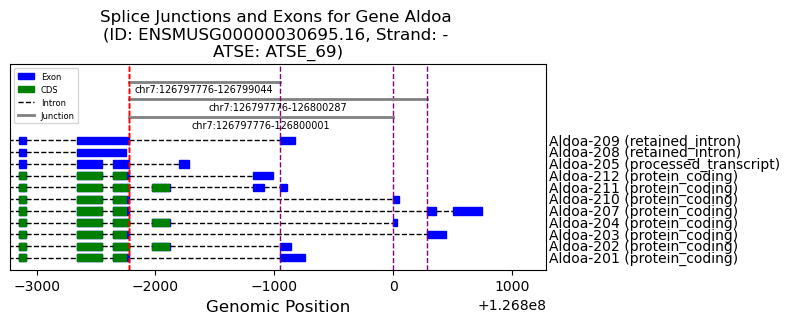

In [14]:
# Example usage:
unique_transcripts = extract_unique_transcripts(juncs)
print(f"Found {len(unique_transcripts)} unique transcripts")

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = fetch_transcripts_and_annotations(db, unique_transcripts)

# From trancsript data get transcript_id to transcript_name to transcript_type mapping
conversions = {}
for t in transcript_data.keys():
    transcript_id = transcript_data[t]["transcript_id"]
    transcript_name = transcript_data[t]["transcript_name"]
    transcript_type = transcript_data[t]["transcript_type"]
    conversions[transcript_id] = {
        "transcript_name": transcript_name,
        "transcript_type": transcript_type, 
        "transcript_id": transcript_id
    } 

# convert to dataframe 
conversions_df = pd.DataFrame.from_dict(conversions, orient='index')
print(conversions_df)

# Plot the junctions/transcripts involved in the ATSE 
region_start, region_end = determine_region_boundaries(splice_junctions)
plot_exons_and_junctions(db, atse_event, transcript_data, splice_junctions, region_start, region_end, 
                         base_width=8, trans_height=0.2, show_usage=False, show_junc_lines=True, filename="test.pdf")

# TO-DO:
# - Return plot as a plot object that users can add additional things to... matplotlib object? ax... concatenate... 
# - Feed in OG Leafcutter Intron Clusters... via intron cluster table... 
# - Feed in the Junction by Sample Table as input to junction annoation... BED file with extra columns... 
# - Similar to isoform plots, implement the intron scaling thing
# - VIsulize multiple ATSEs per gene wuld be nice 
# - Test on BigBrain bulk RNA-seq files 
# - Test on EasySci junctions 
# - sQTLs or other SNPs would be nice to visualize... 

In [17]:
juncs.iloc[2]["perfect_match_5_prime"], juncs.iloc[2]["perfect_match_3_prime"]

('ENSMUST00000032934.11,ENSMUST00000087566.10,ENSMUST00000147748.1,ENSMUST00000205336.1',
 'ENSMUST00000032934.11,ENSMUST00000106348.7,ENSMUST00000087566.10,ENSMUST00000135707.7,ENSMUST00000151137.7,ENSMUST00000205890.1,ENSMUST00000147748.1,ENSMUST00000141355.3,ENSMUST00000205336.1,ENSMUST00000133514.7')